# Replicate Fig. 5.21 
("Understanding Vision", Li Zhaoping, 2014)

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from v1sh_model.inputs.visualize import visualize_input, visualize_output, plot_bars_colored
from v1sh_model.models.V1_model import V1_model
from v1sh_model.inputs.examples import neighboring_textures

In [2]:
# Instantiate and test the FullModel
seed = 60
model = V1_model(seed=seed, alpha_x=1.0, alpha_y=1.0, average_noise_height = 0.1, average_noise_temporal_width = 0.01)
A, C = neighboring_textures(22, 60, 2.0) # Fig. 5.21: 22 rows by 60 columns, input contrast 2.0

T = 12.0
dt = 0.01
X_gen, Y_gen, I = model.simulate(
    A, C, dt=dt, T=T, verbose=False, noisy=False, mode="wrap"
)

Use computed connections.


Simulating: 100%|██████████| 1200/1200 [00:37<00:00, 31.68step/s]


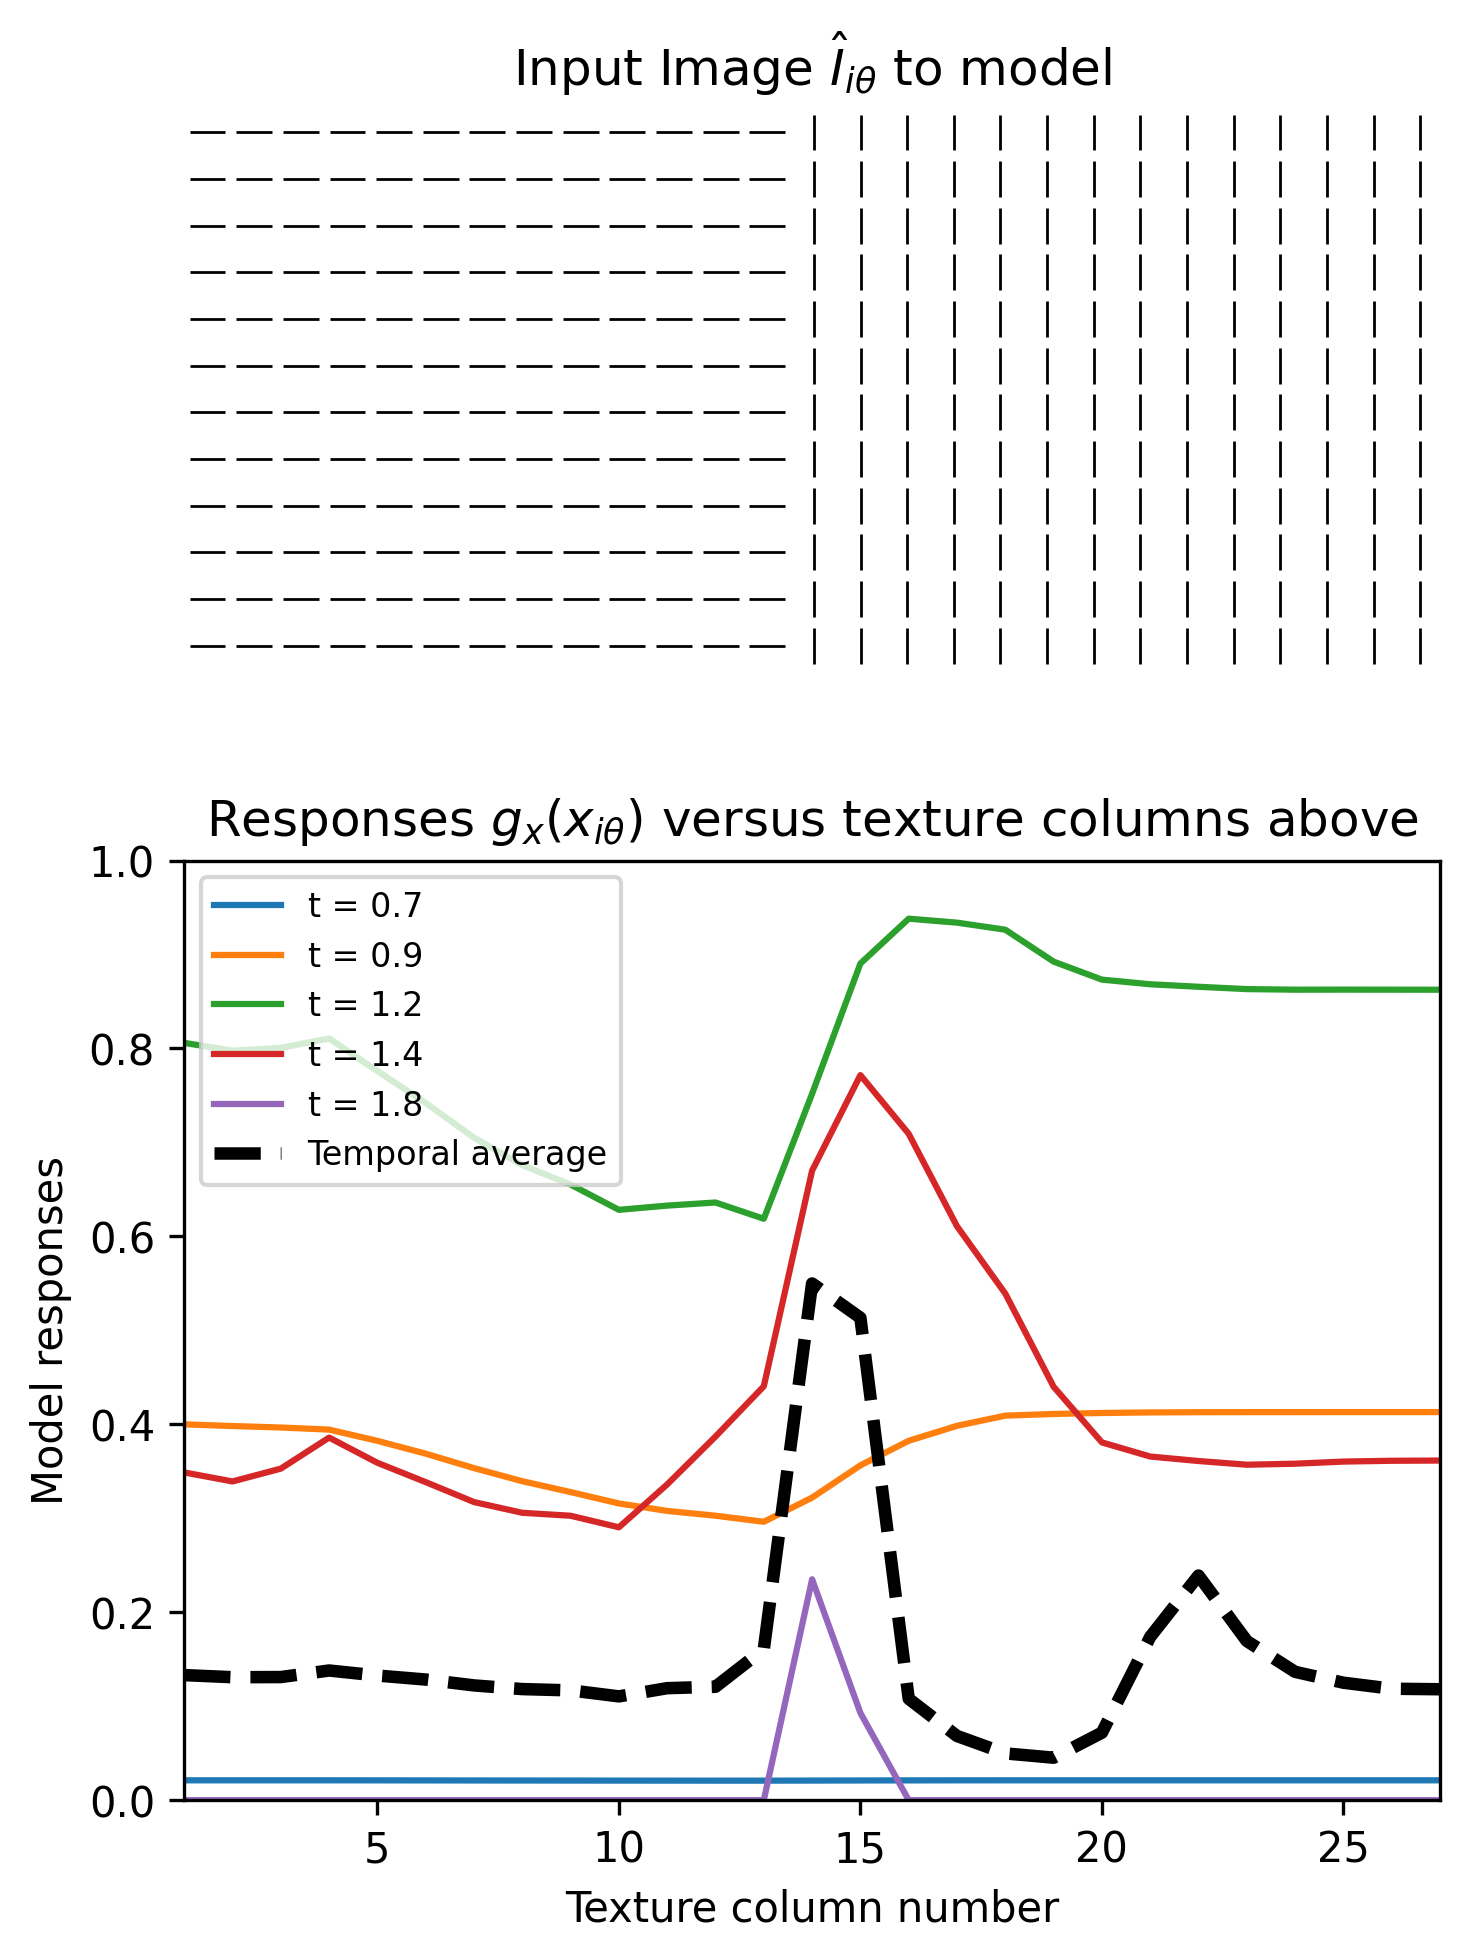

In [3]:
# Time points in seconds to plot
time_points = np.array([0.7, 0.9, 1.2, 1.4, 1.8])
steps = [int(t / dt) for t in time_points]

# average of input across columns for the orientation of the target bar
middle = int(X_gen.shape[2] / 2)
X_per_column = np.concatenate(
    [model.g_x(X_gen[:, :, :middle, 6]).mean(axis=1), model.g_x(X_gen[:, :, middle:, 0]).mean(axis=1)], axis=1
)

# Focus on the central 26 columns
X_per_column_plot = X_per_column[:, 30-13:30+14] 
A_plot = A[:12, 30-13:30+14]
C_plot = C[:12, 30-13:30+14]

# Plot input
fig, axes = plt.subplots(2, 1, figsize=(5, 7), dpi=300)
visualize_input(A_plot, C_plot, verbose=False, axis=axes[0])
axes[0].set_title(r"Input Image $\hat{I}_{i \theta}$ to model")

# Plot model dynamics, see fig. 5.21 in "Understanding Vision" (Li Zhaoping, 2014) 
x_axis = np.arange(X_per_column_plot.shape[1])  # column indices
for t_idx, step in zip(time_points, steps):
    response = X_per_column_plot[step]
    axes[1].plot(x_axis, response, label=f"t = {t_idx:.1f}")

avg_response = X_per_column_plot.mean(axis=0)
axes[1].plot(
    x_axis, avg_response, label="Temporal average", linewidth=3, linestyle="--", color="k"
)
axes[1].set_title(r"Responses $g_x(x_{i\theta})$ versus texture columns above")

axes[1].set_xlabel("Texture column number")
axes[1].set_ylabel("Model responses")
axes[1].set_xticks(np.arange(4, X_per_column_plot.shape[1]+1, 5))
axes[1].set_xticklabels([str(i+1) for i in np.arange(4, X_per_column_plot.shape[1]+1, 5)])
axes[1].set_xlim(0, X_per_column_plot.shape[1]-1)
axes[1].set_ylim(0, 1.0)
axes[1].legend(framealpha=0.8, loc="upper left", fontsize=8)
axes[1].grid(False)
plt.tight_layout()
plt.show()

## For presentation:

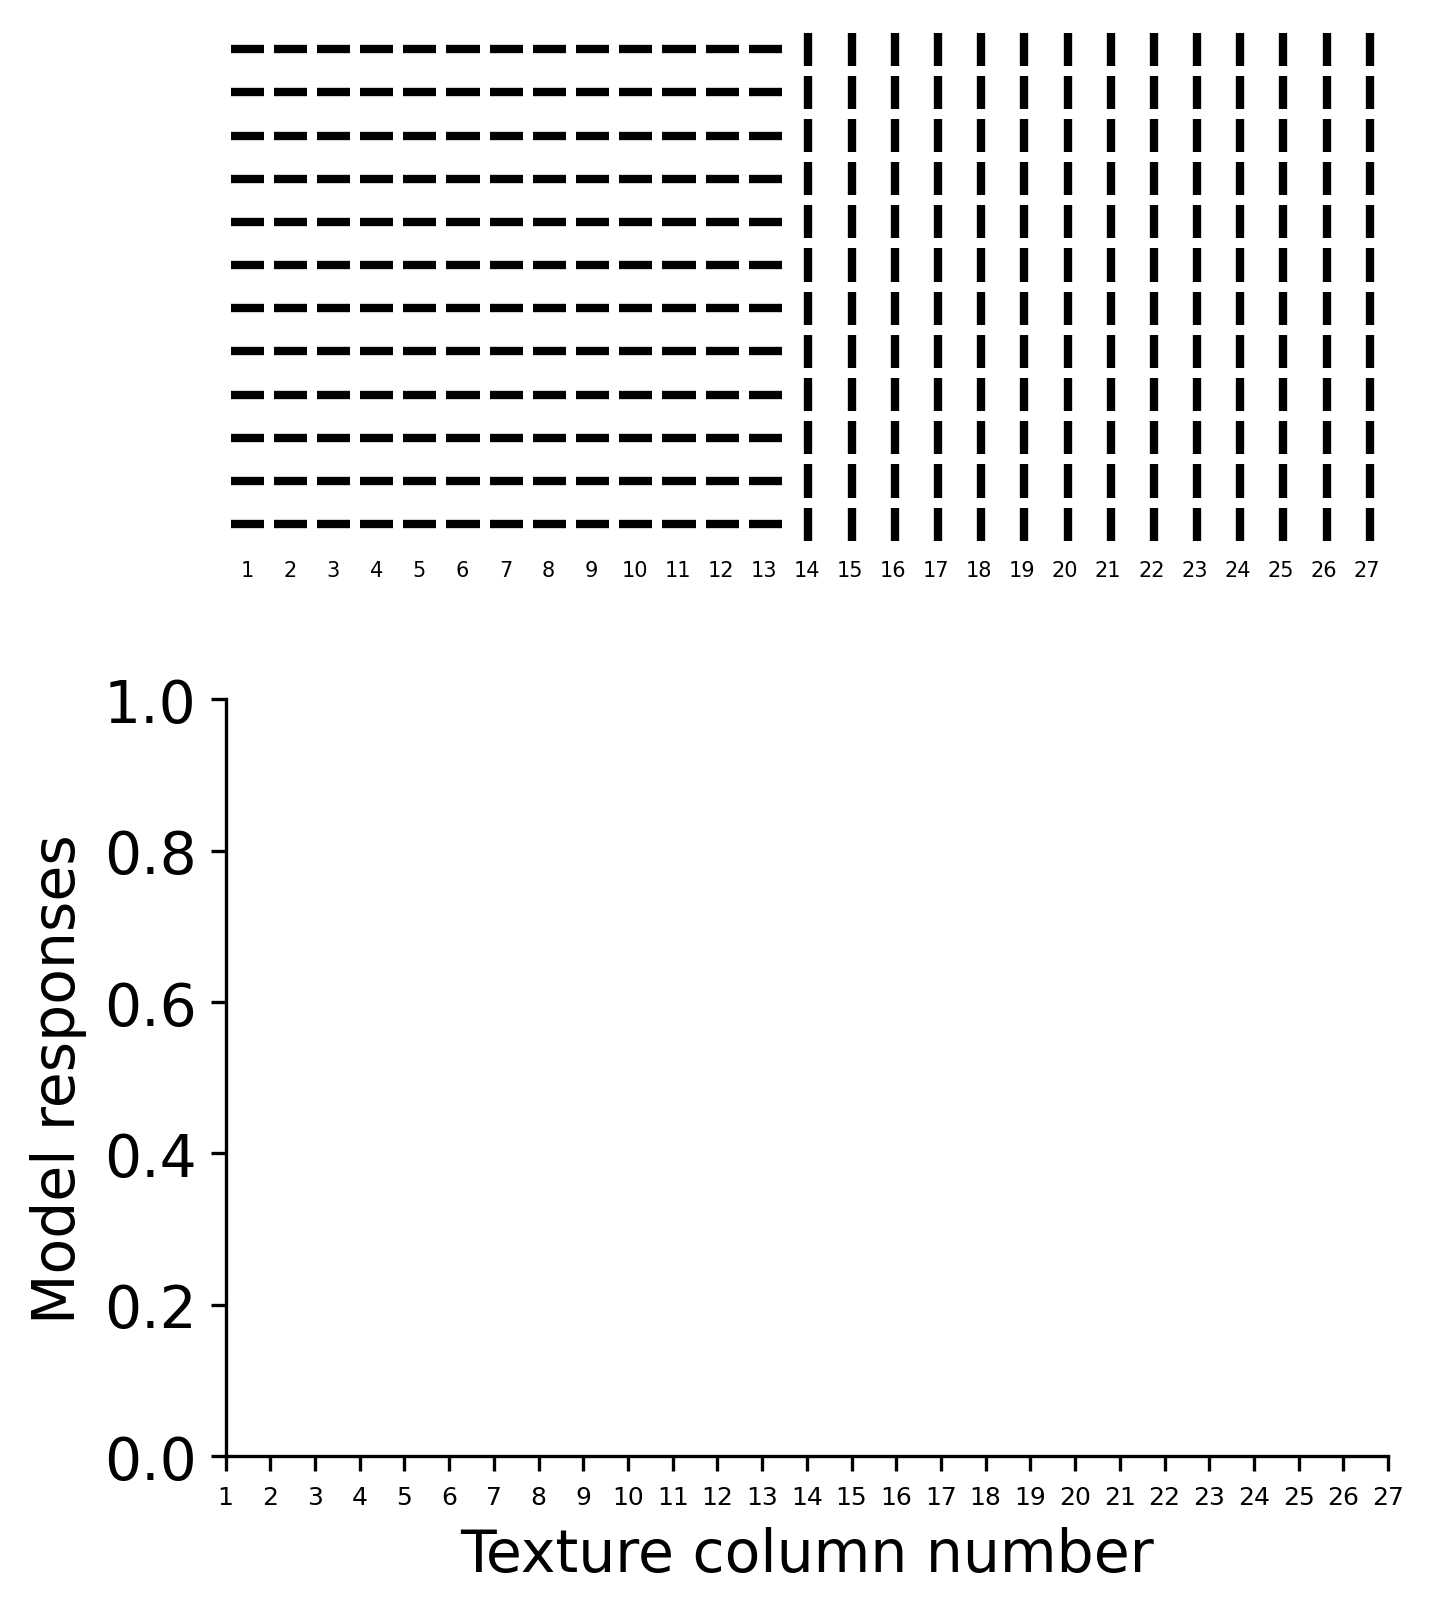

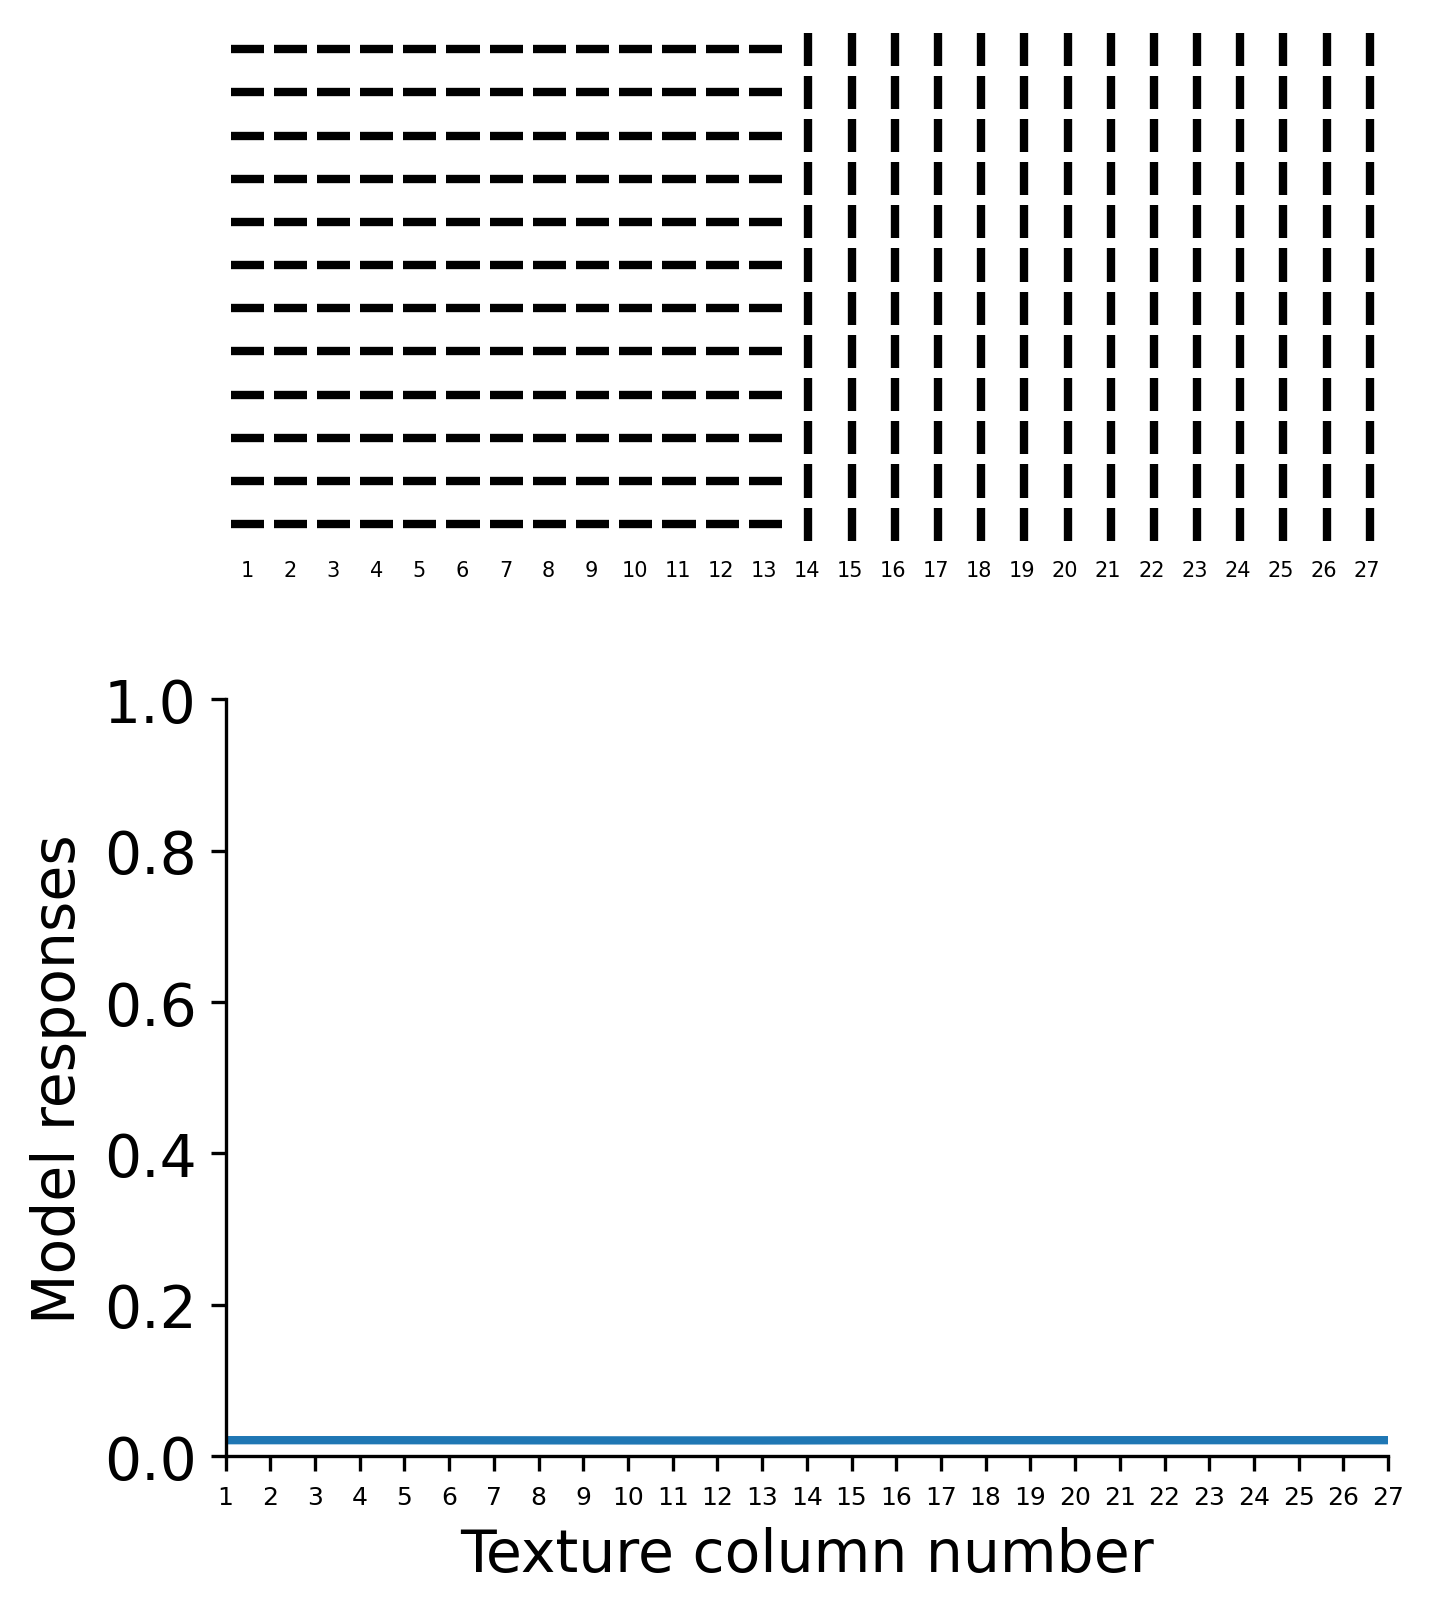

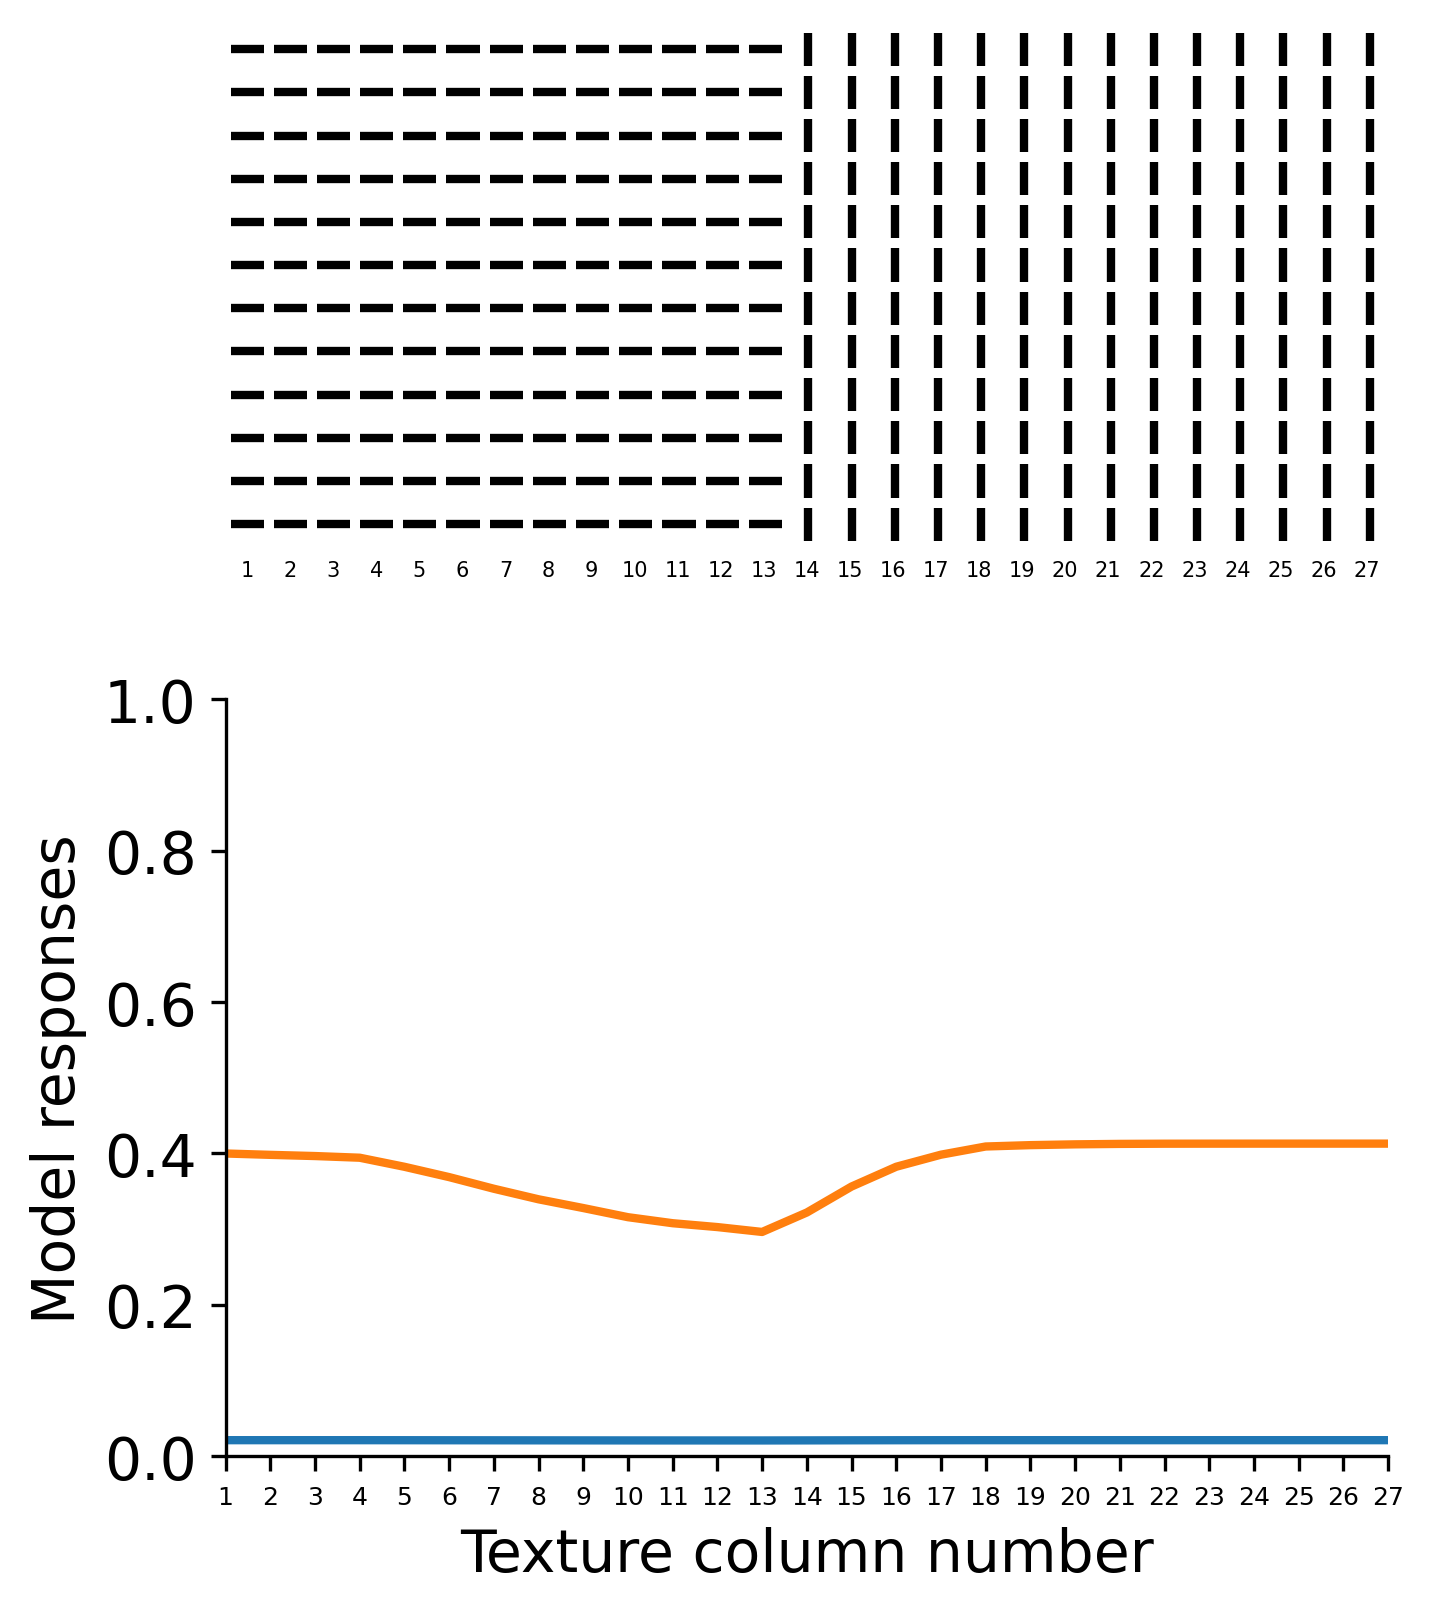

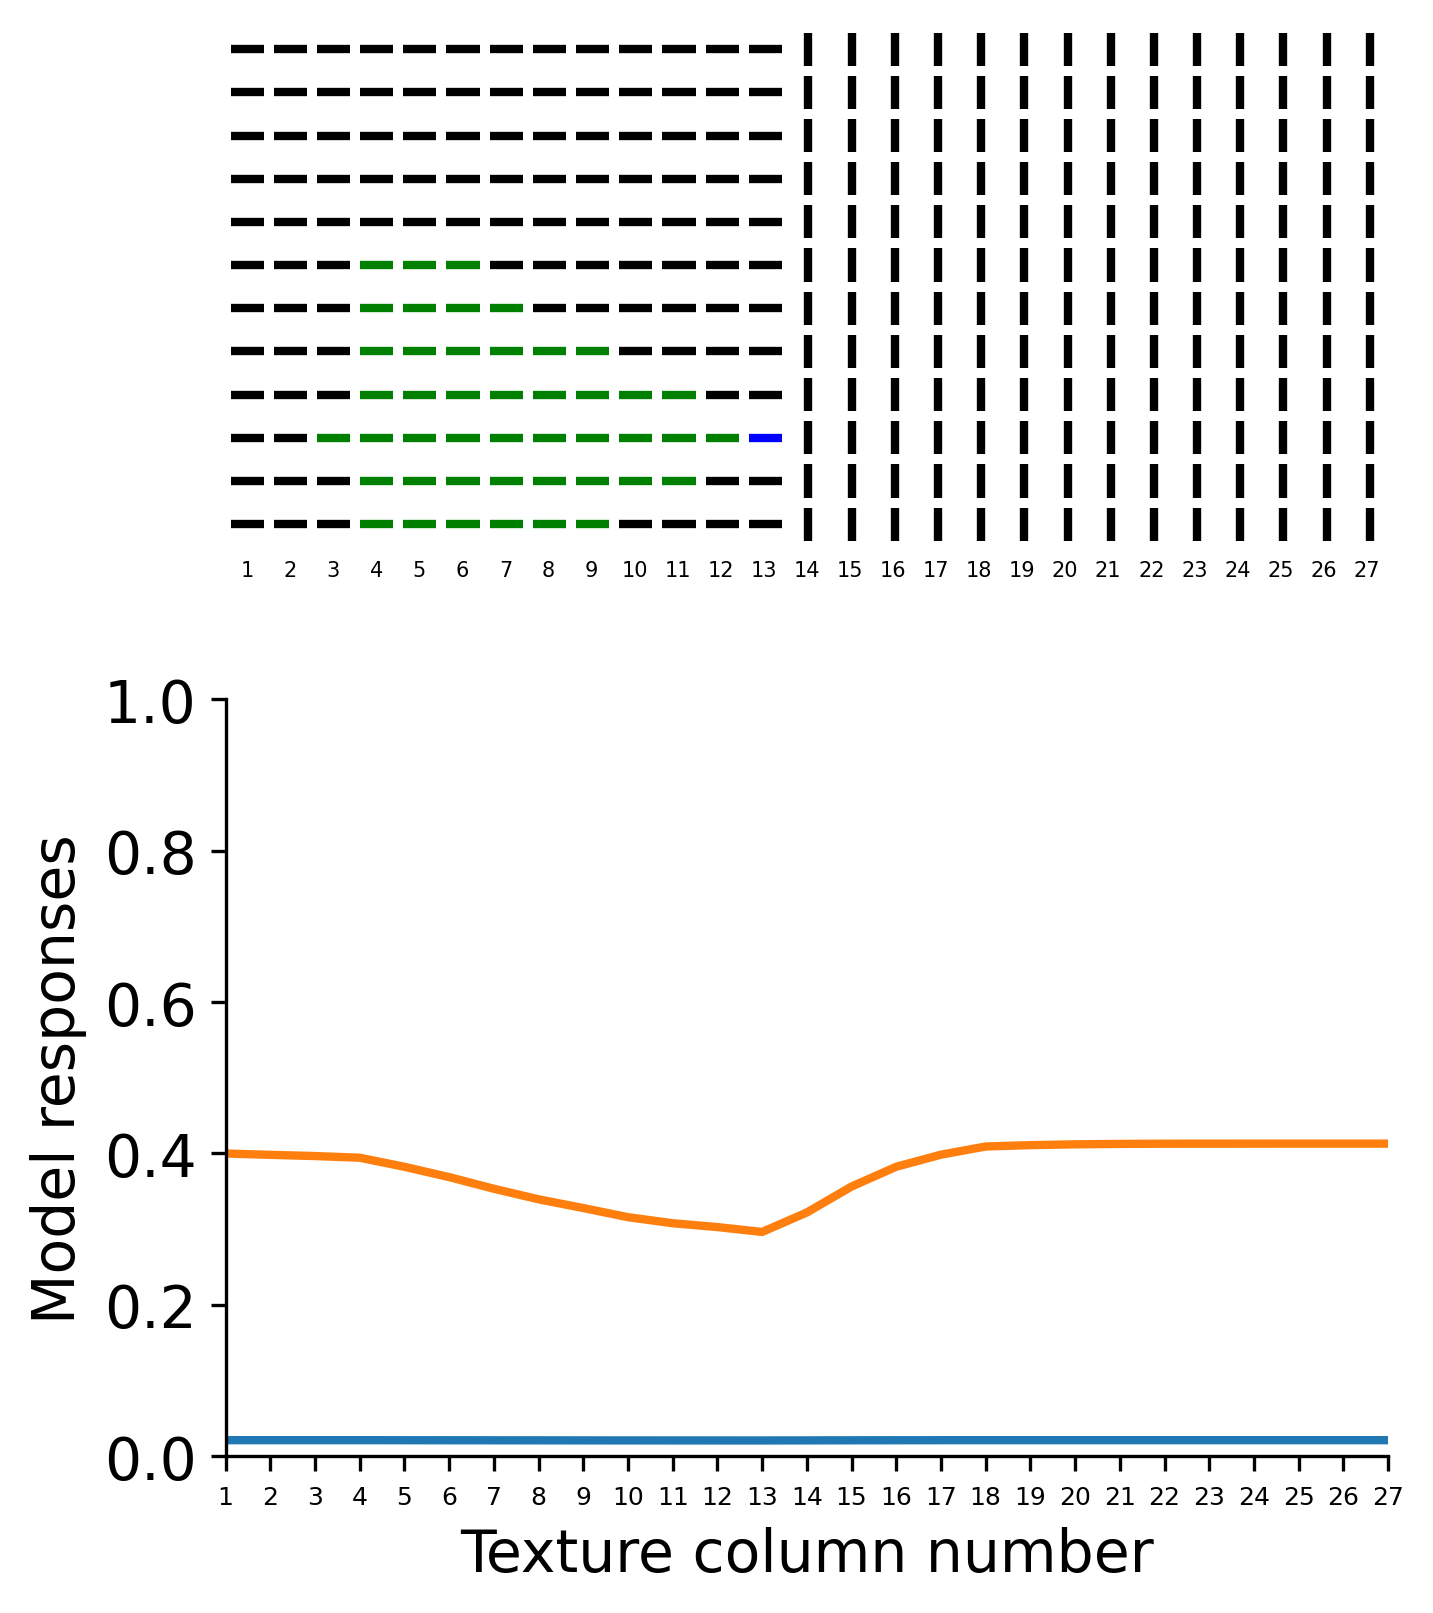

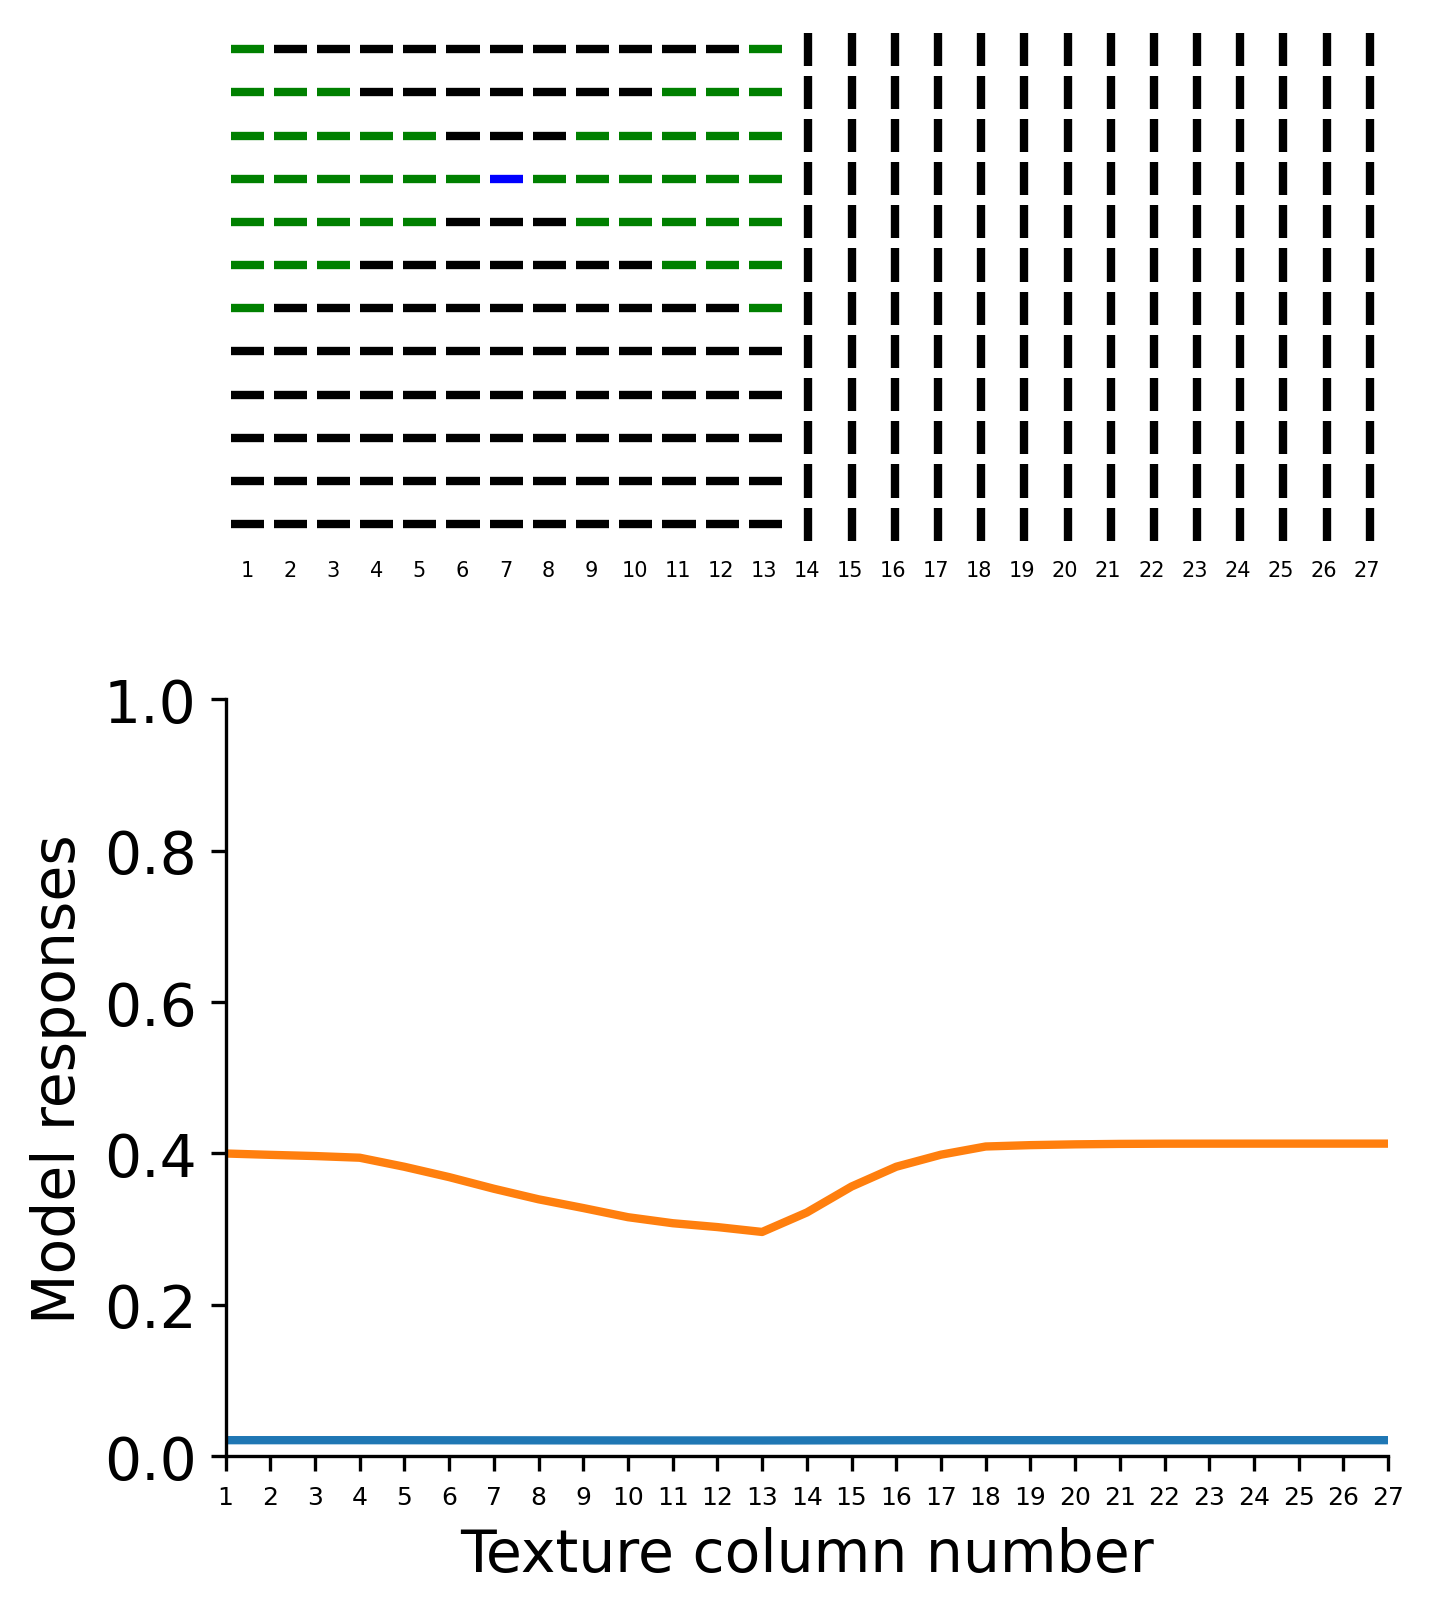

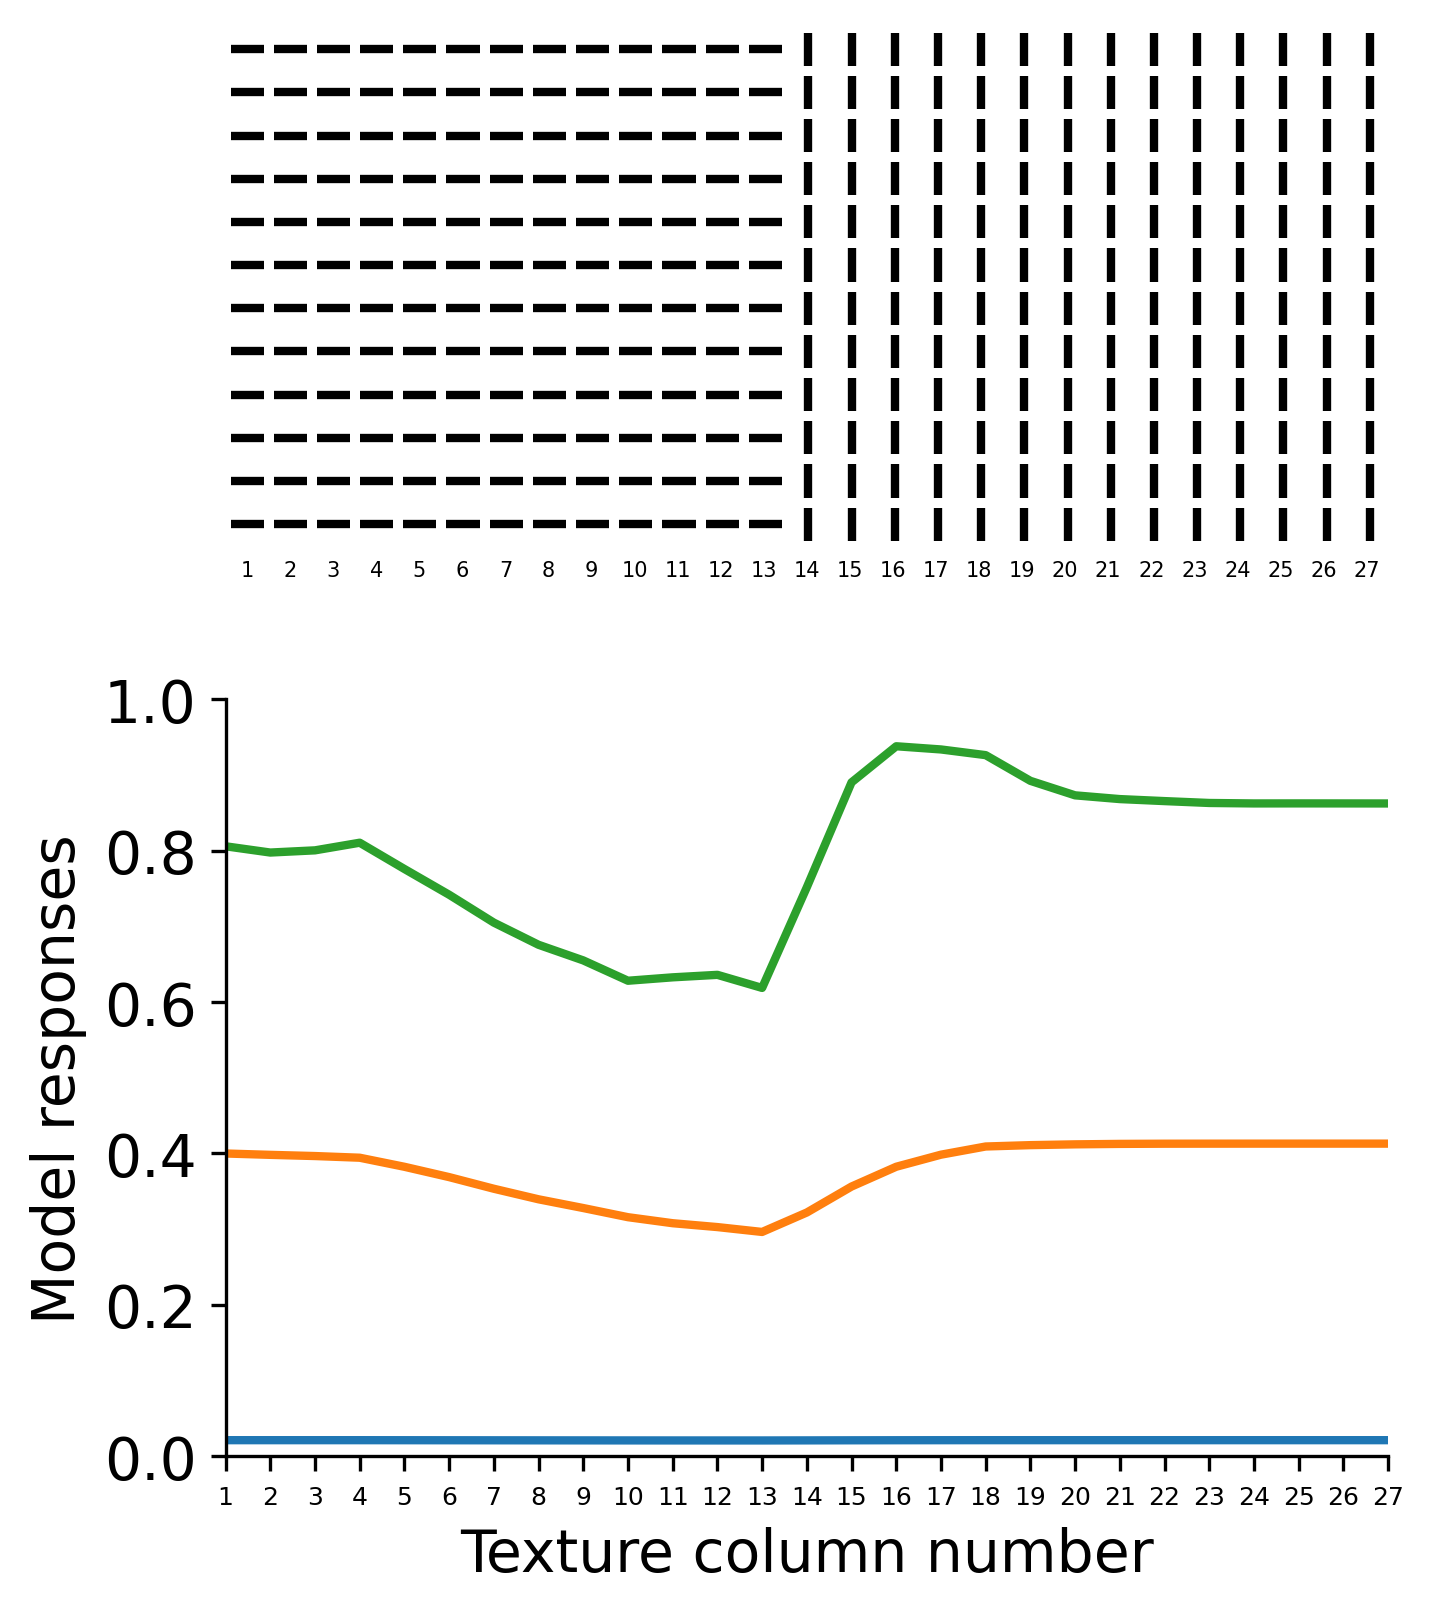

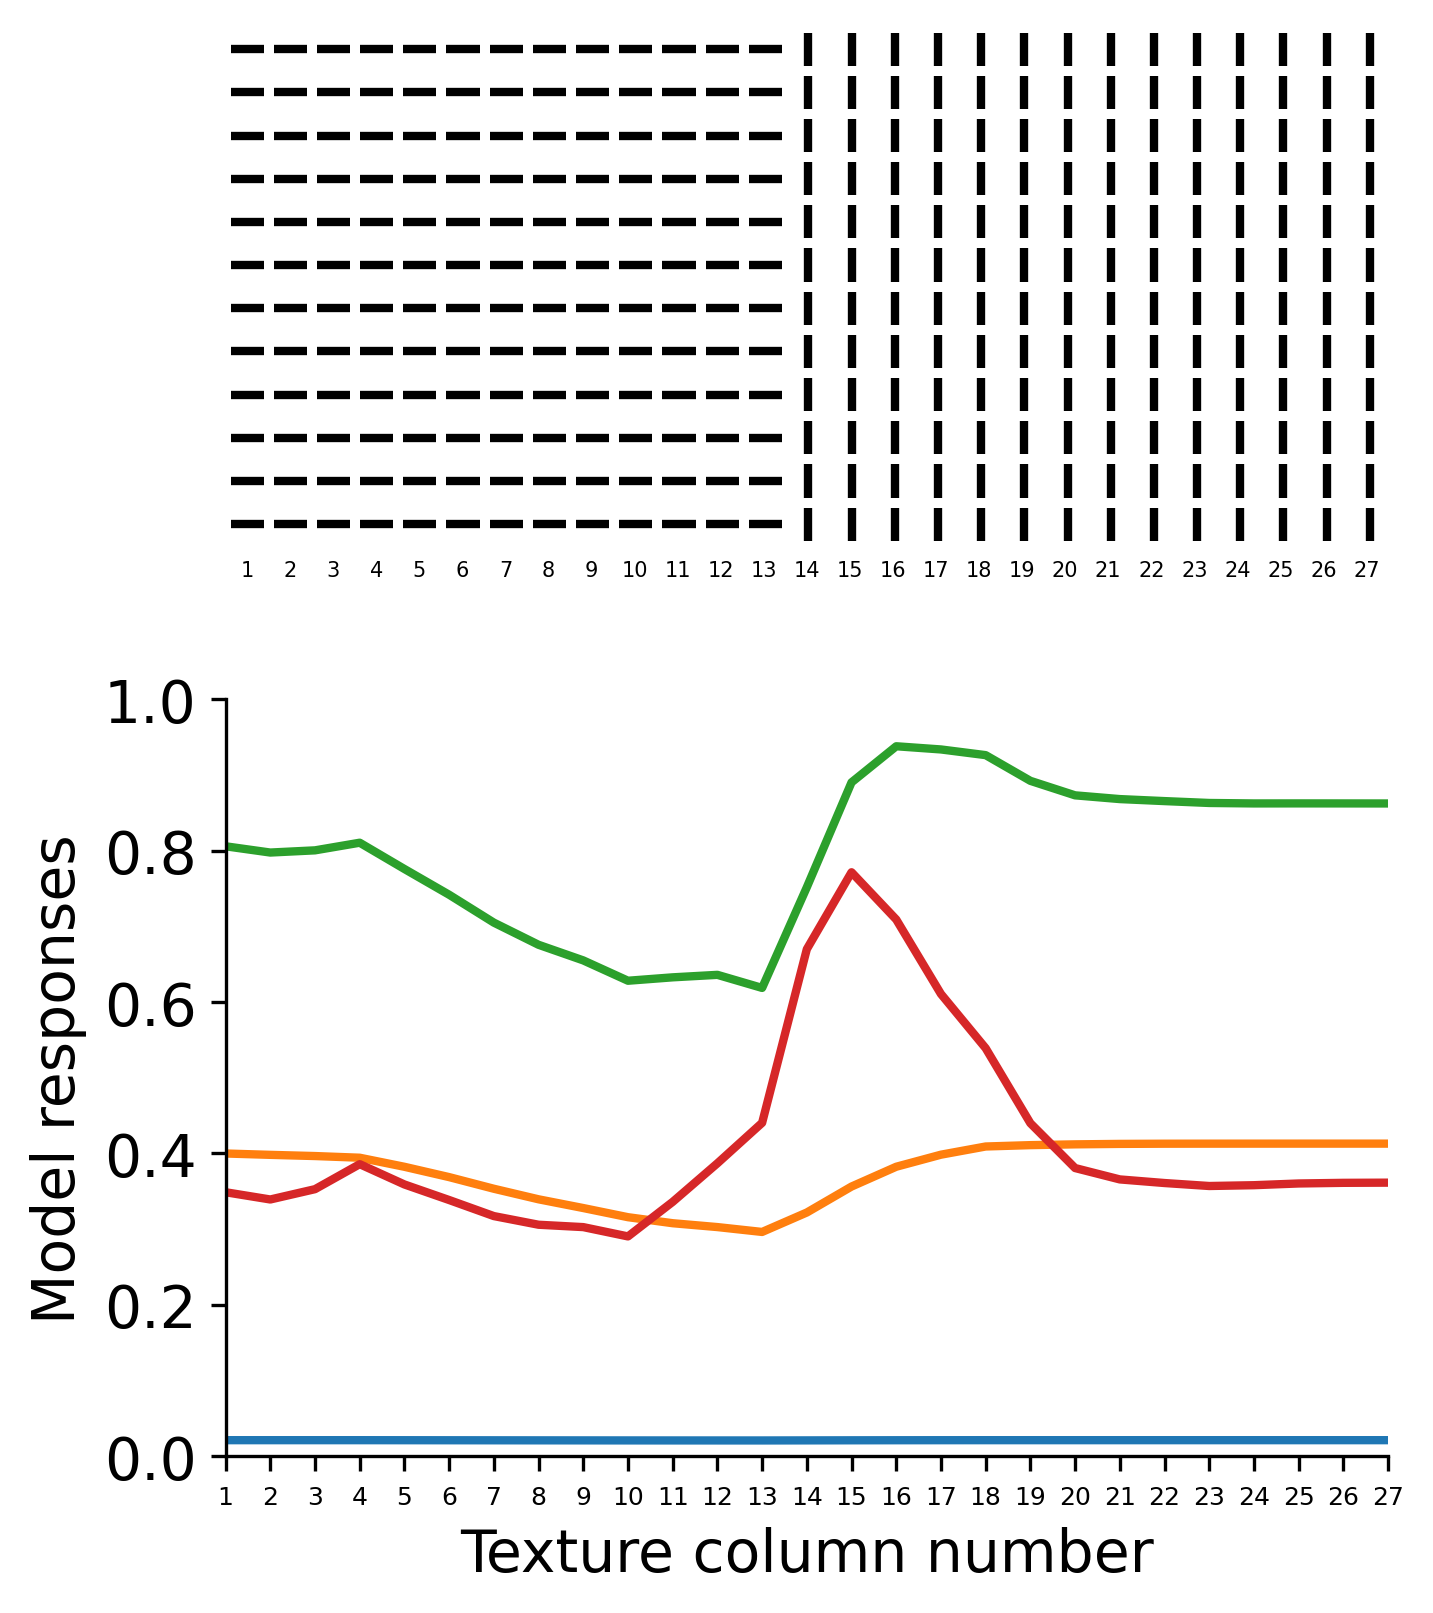

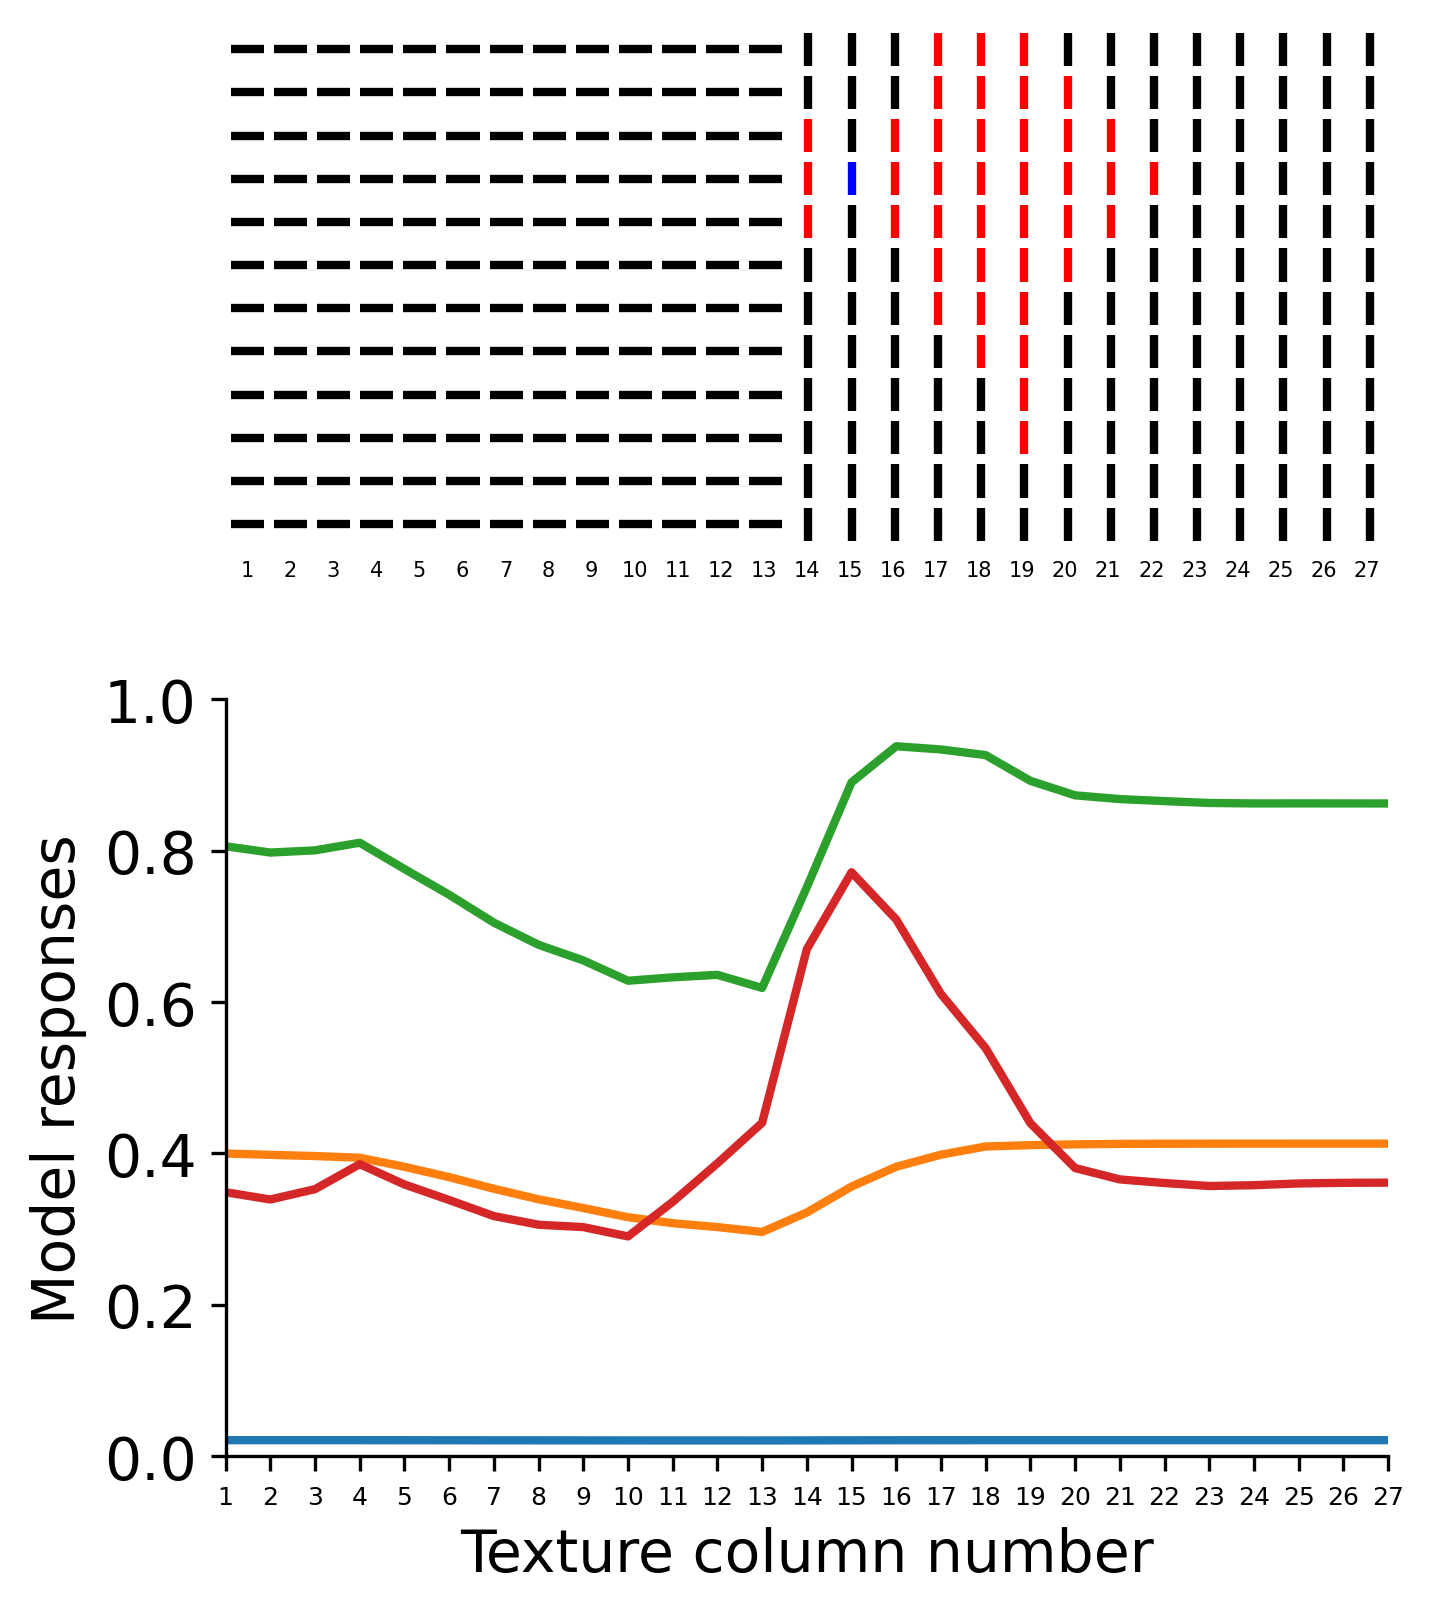

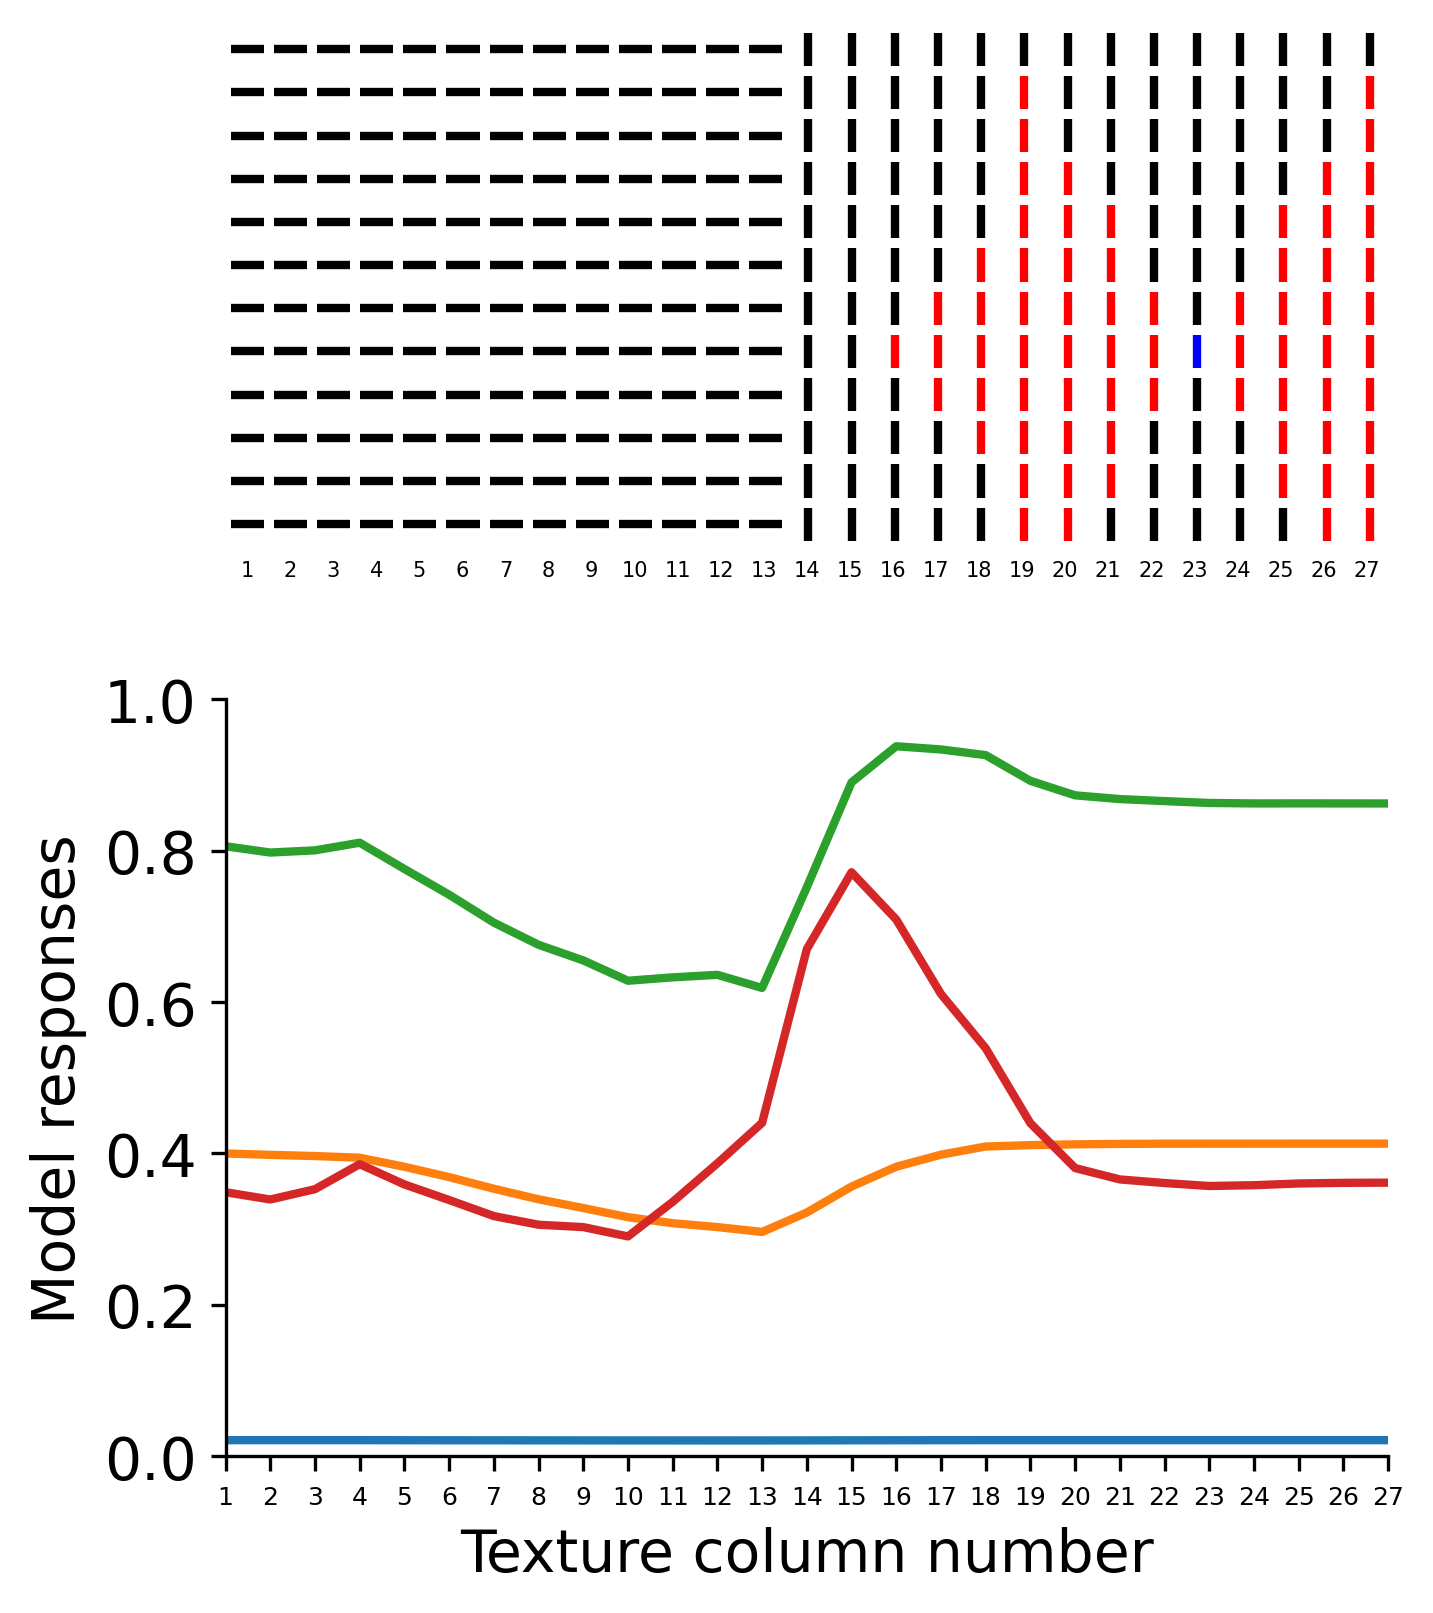

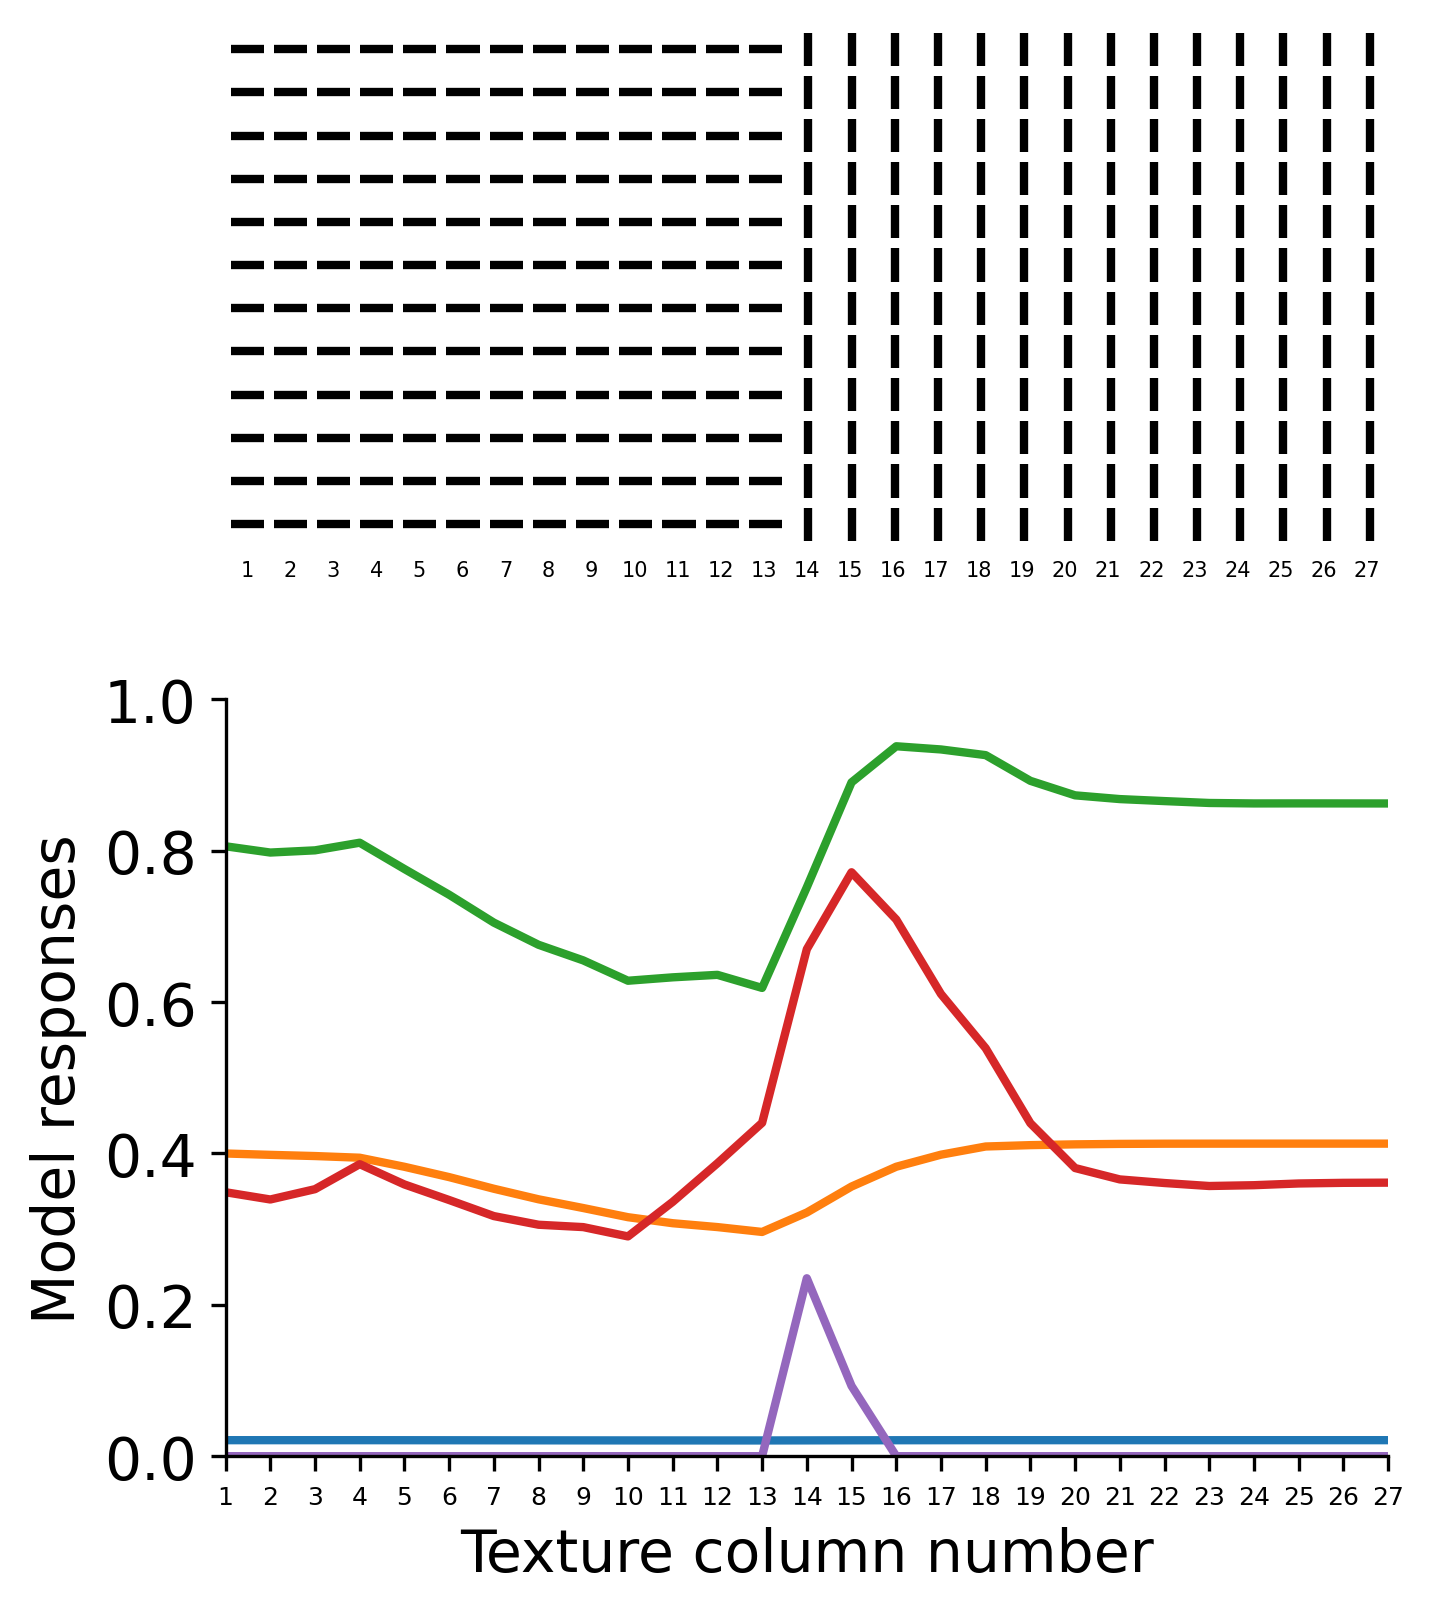

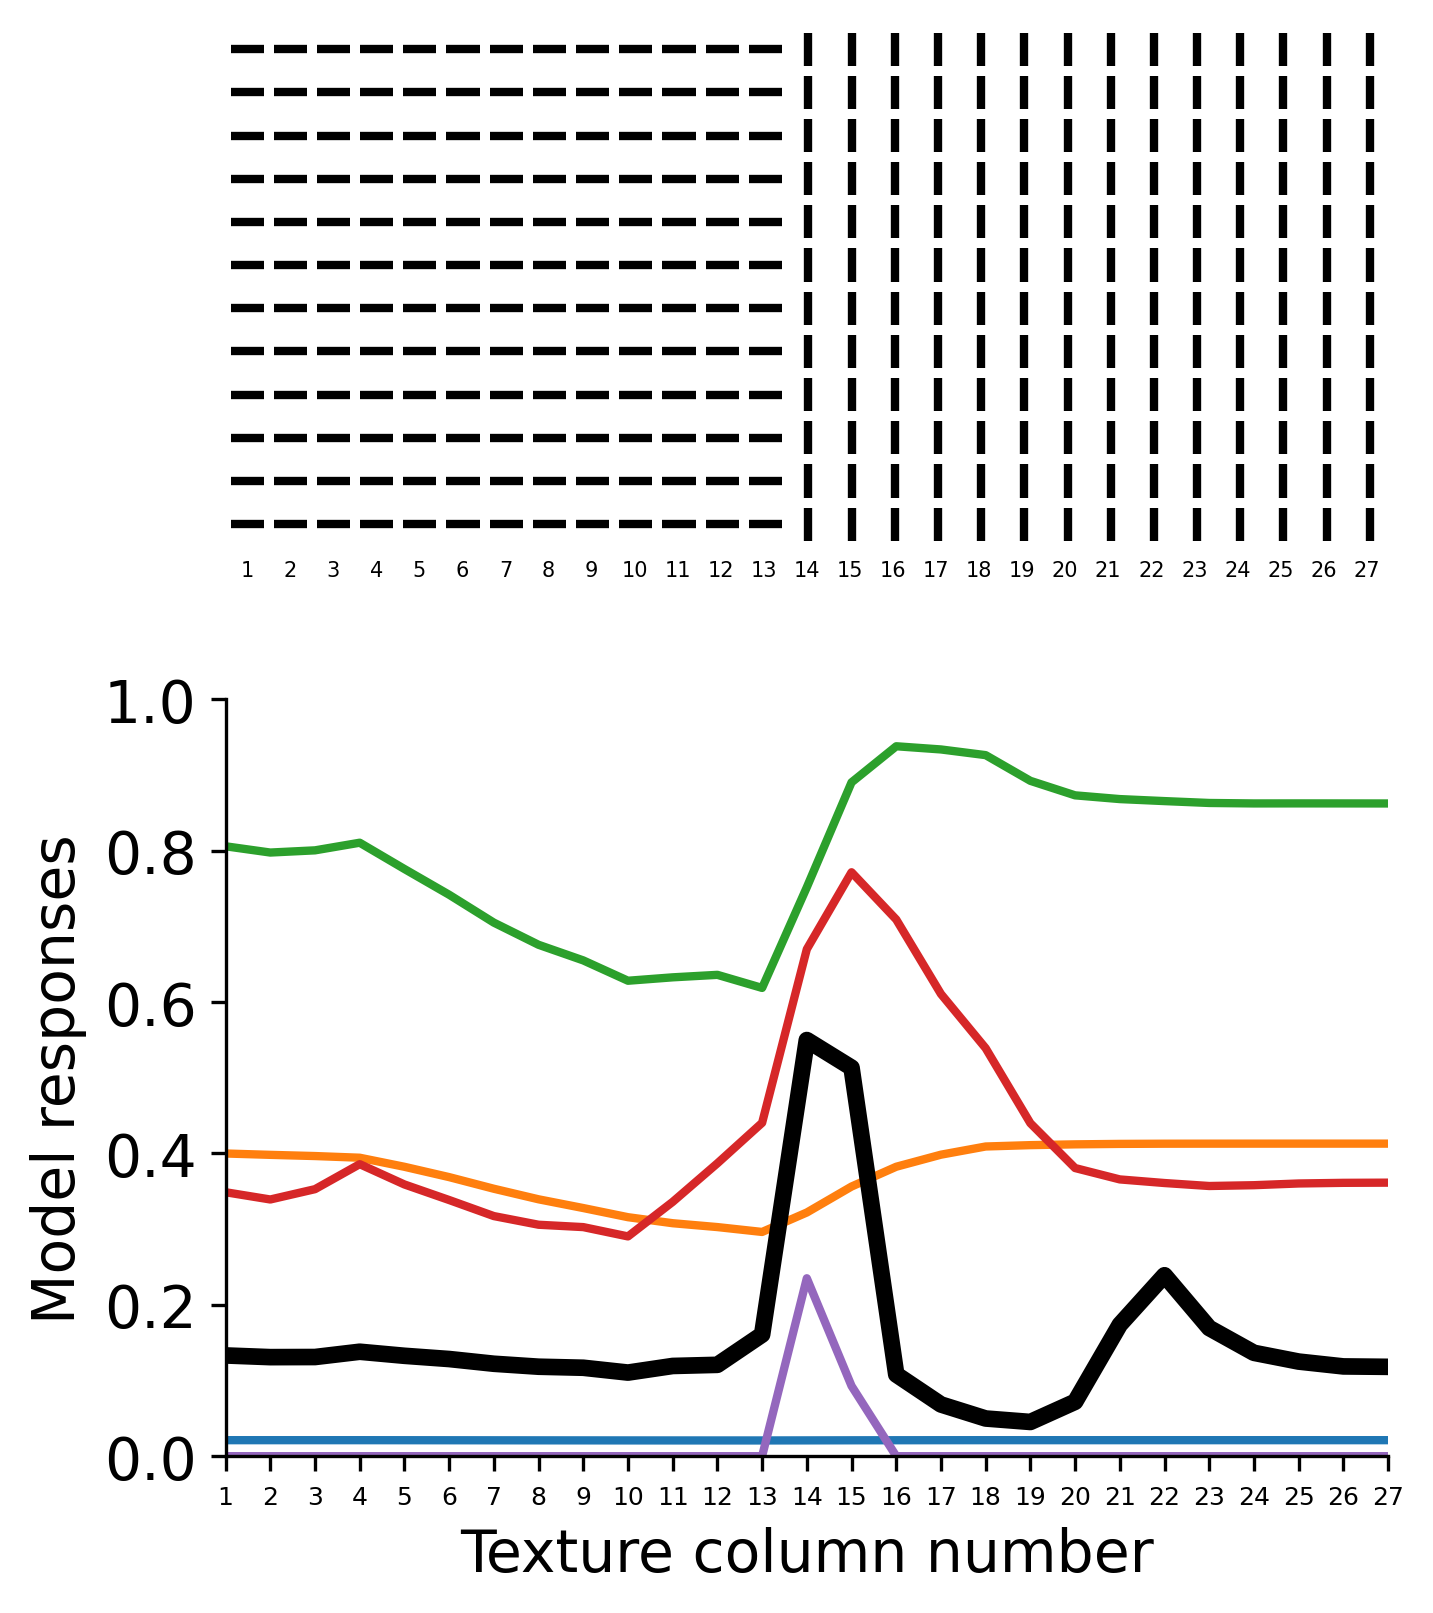

In [4]:
plt.rcParams.update({'font.size': 14})

# Time points in seconds to plot
time_points = np.array([0.7, 0.9, 1.2, 1.4, 1.8])
steps = [int(t / dt) for t in time_points]

# coloring
neurons_to_color = {0.9: [None, (2, 12, 6, "e"), (8, 6, 6, "e")], 1.4: [None, (8, 14, 0, "i"), (4, 22, 0, "i")]} # [(y, x, k), ...], None == no color map
W, J = model.W, model.J
color_dict = {0: "black", 1: "red", 2: "green", 3: "blue"}

# average of input across columns for the orientation of the target bar
middle = int(X_gen.shape[2] / 2)
X_per_column = np.concatenate(
    [model.g_x(X_gen[:, :, :middle, 6]).mean(axis=1), model.g_x(X_gen[:, :, middle:, 0]).mean(axis=1)], axis=1
)

# Focus on the central 26 columns
N_y, N_x = A.shape
X_per_column_plot = X_per_column[:, 30-13:30+14] 
A_plot = A[:12, 30-13:30+14]
C_plot = C[:12, 30-13:30+14]

for stop_idx in range(0, len(steps) + 2):
    if 1 < stop_idx < len(time_points) and (time_points[stop_idx - 1] in neurons_to_color):
        for presynaptic_idx in neurons_to_color[time_points[stop_idx - 1]]:
            # Plot input
            fig, axes = plt.subplots(2, 1, figsize=(5, 6), dpi=300)

            color_map = np.zeros((N_y, N_x, model.K), dtype=int)
            
            # compute colormap
            if presynaptic_idx is not None:
                y_pre, x_pre, k_pre, type = presynaptic_idx
                x_pre = x_pre + 30 - 13  # adjust x coordinate for plotting region
                y_min = max(0, y_pre - 10)
                y_max = min(N_y, y_pre + 11)
                x_min = max(0, x_pre - 10)
                x_max = min(N_x, x_pre + 11)
                if "i" in type:
                    color_map[y_min:y_max, x_min:x_max, :] += 1 * (W[10 - (y_pre - y_min):11 + (y_max - y_pre), 10 - (x_pre - x_min):11 + (x_max - x_pre), k_pre] > 0)
                if "e" in type:
                    color_map[y_min:y_max, x_min:x_max, :] += 2 * (J[10 - (y_pre - y_min):11 + (y_max - y_pre), 10 - (x_pre - x_min):11 + (x_max - x_pre), k_pre]  > 0)
                color_map[y_pre, x_pre, k_pre] = 3  # mark presynaptic neuron
            
            color_map_plot = np.concatenate([color_map[:, :middle, 6], color_map[:, middle:, 0]], axis=1)
            color_map_plot = color_map_plot[:12, 30-13:30+14]
            # show plot
            plot_bars_colored(
                A_plot,
                C_plot,
                color_map=color_map_plot,
                verbose=False,
                color_dict=color_dict,
                axis=axes[0]
                # plot_priority = C_plot, # plot bars in order of increasing activity
            )
        
            axes[0].axis("on")
            axes[0].set_frame_on(False)
            # axes[0].set_title(r"Input Image")
            axes[0].set_yticks([])
            xmin, xmax = axes[0].get_xlim()
            n_cols_plot = A_plot.shape[1]
            xticks_distance = (xmax-xmin) / n_cols_plot
            axes[0].set_xticks(np.arange(xmin + xticks_distance/2, xmax, xticks_distance), labels=np.arange(1, n_cols_plot + 1))
            axes[0].tick_params(axis='x', length=0) 
            axes[0].tick_params(axis='x', labelsize=5) 
        
            plt.subplots_adjust(hspace=0.01)

            # Plot model dynamics, see fig. 5.21 in "Understanding Vision" (Li Zhaoping, 2014) 
            x_axis = np.arange(X_per_column_plot.shape[1])  # column indices
            for t_idx, step in zip(time_points[:stop_idx], steps[:stop_idx]):
                response = X_per_column_plot[step]
                axes[1].plot(x_axis, response, label=f"t = {t_idx:.1f}", linewidth = 2)
            axes[1].spines['top'].set_visible(False)
            axes[1].spines['right'].set_visible(False)

            if stop_idx >= len(steps) + 1:
                avg_response = X_per_column_plot.mean(axis=0)
                axes[1].plot(
                    x_axis, avg_response, label="Temporal average", linewidth=4, linestyle="-", color="k"
                )

            axes[1].set_xlabel("Texture column number")
            axes[1].set_ylabel("Model responses")
            axes[1].set_xticks(np.arange(0, X_per_column_plot.shape[1], 1))
            axes[1].set_xticklabels([str(i) for i in np.arange(1, X_per_column_plot.shape[1]+1, 1)])
            axes[1].tick_params(axis='x', labelsize=6) 
            axes[1].set_xlim(0, X_per_column_plot.shape[1]-1)
            axes[1].set_ylim(0, 1.0)
            axes[1].grid(False)
            plt.tight_layout()
            plt.show()
    else:
        # Plot input
        fig, axes = plt.subplots(2, 1, figsize=(5, 6), dpi=300)
        visualize_input(A_plot, C_plot, scale = 1, verbose=False, axis=axes[0])
        
        axes[0].axis("on")
        axes[0].set_frame_on(False)
        # axes[0].set_title(r"Input Image")
        axes[0].set_yticks([])
        xmin, xmax = axes[0].get_xlim()
        n_cols_plot = A_plot.shape[1]
        xticks_distance = (xmax-xmin) / n_cols_plot
        axes[0].set_xticks(np.arange(xmin + xticks_distance/2, xmax, xticks_distance), labels=np.arange(1, n_cols_plot + 1))
        axes[0].tick_params(axis='x', length=0) 
        axes[0].tick_params(axis='x', labelsize=5) 
        
        plt.subplots_adjust(hspace=0.01)

        # Plot model dynamics, see fig. 5.21 in "Understanding Vision" (Li Zhaoping, 2014) 
        x_axis = np.arange(X_per_column_plot.shape[1])  # column indices
        for t_idx, step in zip(time_points[:stop_idx], steps[:stop_idx]):
            response = X_per_column_plot[step]
            axes[1].plot(x_axis, response, label=f"t = {t_idx:.1f}", linewidth = 2)
        axes[1].spines['top'].set_visible(False)
        axes[1].spines['right'].set_visible(False)

        if stop_idx >= len(steps) + 1:
            avg_response = X_per_column_plot.mean(axis=0)
            axes[1].plot(
                x_axis, avg_response, label="Temporal average", linewidth=4, linestyle="-", color="k"
            )

        axes[1].set_xlabel("Texture column number")
        axes[1].set_ylabel("Model responses")
        axes[1].set_xticks(np.arange(0, X_per_column_plot.shape[1], 1))
        axes[1].set_xticklabels([str(i) for i in np.arange(1, X_per_column_plot.shape[1]+1, 1)])
        axes[1].tick_params(axis='x', labelsize=6) 
        axes[1].set_xlim(0, X_per_column_plot.shape[1]-1)
        axes[1].set_ylim(0, 1.0)
        axes[1].grid(False)
        plt.tight_layout()
        plt.show()